<a href="https://colab.research.google.com/github/Anirudh-Saini10/Image-Denoising-by-Convolutional-Autoencoders/blob/main/Image_Denoising_Aniruddha_Saini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Denoising Using Convolutional Autoencoders (CV Project)
**Name:** Aniruddha Saini  
**Roll No:** 23FE10CAI00358  
**Course:** Computer Vision

Data Loading and Adding Noise

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Load MNIST
transform = transforms.ToTensor()

train_data = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=128, shuffle=False)

# Function to add Gaussian noise
def add_noise(images, noise_factor=0.4):
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0., 1.)  # keep pixel values between 0 and 1

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.2MB/s]


Building and Training the Autoencoder

In [2]:



import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = ConvAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
losses = []

for epoch in range(20):
    model.train()
    total_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = add_noise(images).to(device)
        outputs = model(noisy_images)
        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/20] Loss: {avg_loss:.4f}")

Epoch [1/20] Loss: 0.0580
Epoch [2/20] Loss: 0.0128
Epoch [3/20] Loss: 0.0114
Epoch [4/20] Loss: 0.0108
Epoch [5/20] Loss: 0.0105
Epoch [6/20] Loss: 0.0102
Epoch [7/20] Loss: 0.0100
Epoch [8/20] Loss: 0.0099
Epoch [9/20] Loss: 0.0098
Epoch [10/20] Loss: 0.0097
Epoch [11/20] Loss: 0.0096
Epoch [12/20] Loss: 0.0095
Epoch [13/20] Loss: 0.0094
Epoch [14/20] Loss: 0.0094
Epoch [15/20] Loss: 0.0093
Epoch [16/20] Loss: 0.0092
Epoch [17/20] Loss: 0.0092
Epoch [18/20] Loss: 0.0091
Epoch [19/20] Loss: 0.0091
Epoch [20/20] Loss: 0.0091


Evaluation and Visualization

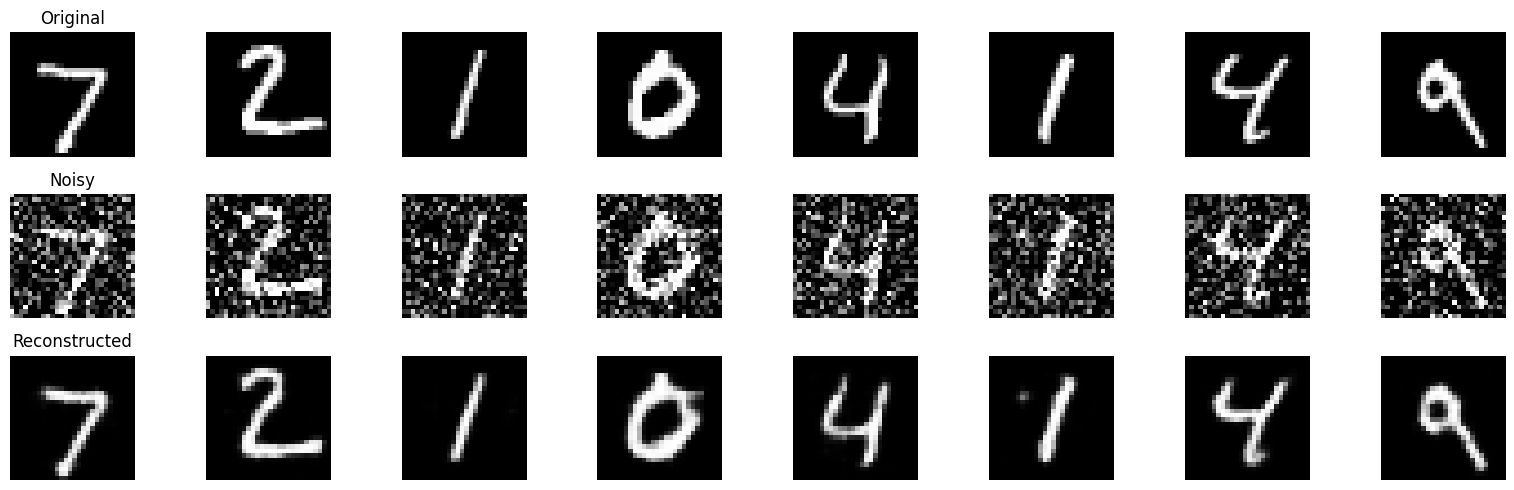

In [3]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        noisy_images = add_noise(images).to(device)
        reconstructed = model(noisy_images)
        break  # just take one batch

# Plot: Original | Noisy | Reconstructed
n = 8
fig, axes = plt.subplots(3, n, figsize=(16, 5))

for i in range(n):
    # Original
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title('Original')

    # Noisy
    axes[1, i].imshow(noisy_images[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title('Noisy')

    # Reconstructed
    axes[2, i].imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title('Reconstructed')

plt.tight_layout()
plt.savefig('denoising_results.png', dpi=150)
plt.show()

MSE Evaluation

In [4]:
total_mse = 0
model.eval()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        noisy = add_noise(images).to(device)
        output = model(noisy)
        total_mse += criterion(output, images).item()

print(f"Average Test MSE: {total_mse / len(test_loader):.4f}")

Average Test MSE: 0.0089


Plotting the Loss

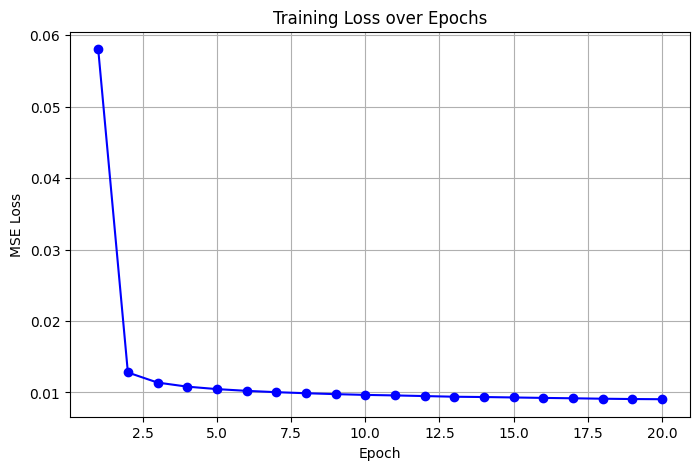

In [5]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(losses)+1), losses, marker='o', color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [6]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

def denoise_demo(noise_factor):
    model.eval()
    # grab one test image
    test_img, _ = next(iter(test_loader))
    test_img = test_img[0:1].to(device)

    noisy = test_img + noise_factor * torch.randn_like(test_img)
    noisy = torch.clamp(noisy, 0., 1.)

    with torch.no_grad():
        output = model(noisy)

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(test_img.cpu().squeeze(), cmap='gray')
    axes[0].set_title("Original")
    axes[1].imshow(noisy.cpu().squeeze(), cmap='gray')
    axes[1].set_title(f"Noisy (σ={noise_factor})")
    axes[2].imshow(output.cpu().squeeze(), cmap='gray')
    axes[2].set_title("Denoised")
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

slider = widgets.FloatSlider(value=0.5, min=0.1, max=1.0, step=0.1, description='Noise:')
widgets.interact(denoise_demo, noise_factor=slider)

interactive(children=(FloatSlider(value=0.5, description='Noise:', max=1.0, min=0.1), Output()), _dom_classes=…

<function __main__.denoise_demo(noise_factor)>